## Weather Forecasting Model Traning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv('../data/raw/max_planck_weather_ts.csv')
print("Shape of the dataset:", df.shape)
df.head()

Shape of the dataset: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420551 non-null  str    
 1   p (mbar)         420551 non-null  float64
 2   T (degC)         420551 non-null  float64
 3   Tpot (K)         420551 non-null  float64
 4   Tdew (degC)      420551 non-null  float64
 5   rh (%)           420551 non-null  float64
 6   VPmax (mbar)     420551 non-null  float64
 7   VPact (mbar)     420551 non-null  float64
 8   VPdef (mbar)     420551 non-null  float64
 9   sh (g/kg)        420551 non-null  float64
 10  H2OC (mmol/mol)  420551 non-null  float64
 11  rho (g/m**3)     420551 non-null  float64
 12  wv (m/s)         420551 non-null  float64
 13  max. wv (m/s)    420551 non-null  float64
 14  wd (deg)         420551 non-null  float64
dtypes: float64(14), str(1)
memory usage: 48.1 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
p (mbar),420551.0,989.212776,8.358481,913.60,984.20,989.58,994.72,1015.35
T (degC),420551.0,9.450147,8.423365,-23.01,3.36,9.42,15.47,37.28
Tpot (K),420551.0,283.492743,8.504471,250.60,277.43,283.47,289.53,311.34
Tdew (degC),420551.0,4.955854,6.730674,-25.01,0.24,5.22,10.07,23.11
rh (%),420551.0,76.008259,16.476175,12.95,65.21,79.30,89.40,100.00
VPmax (mbar),420551.0,13.576251,7.739020,0.95,7.78,11.82,17.60,63.77
VPact (mbar),420551.0,9.533756,4.184164,0.79,6.21,8.86,12.35,28.32
VPdef (mbar),420551.0,4.042412,4.896851,0.00,0.87,2.19,5.30,46.01
sh (g/kg),420551.0,6.022408,2.656139,0.50,3.92,5.59,7.80,18.13
H2OC (mmol/mol),420551.0,9.640223,4.235395,0.80,6.29,8.96,12.49,28.82


In [5]:
# change the string data time to datetime format 
df["Date Time"] = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")

# Duplicate rows ain remove kirima
df = df.drop_duplicates().reset_index(drop=True)

# -9999 kiyana error values NaN (missing) widihata wenas kirima
sentinel_cols = ["wv (m/s)", "max. wv (m/s)"]
for c in sentinel_cols:
    df.loc[df[c] < -1, c] = np.nan

# Missing values (NaN) linear interpolation eken purawanna
df[sentinel_cols] = df[sentinel_cols].interpolate(method="linear", limit_direction="both")

print("Missing values remaining:")
print(df[sentinel_cols].isna().sum())

Missing values remaining:
wv (m/s)         0
max. wv (m/s)    0
dtype: int64


In [6]:
# Outliers hoyaganna IQR method eka hadaganima
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_cols = ["T (degC)", "p (mbar)"]
df_capped = df.copy()

# Outliers cap kirima (winsorize kirima)
for c in outlier_cols:
    lo, hi = iqr_bounds(df[c])
    df_capped[c] = df_capped[c].clip(lower=lo, upper=hi)

df = df_capped
print("Outlier handling complete (capped at IQR bounds).")

Outlier handling complete (capped at IQR bounds).


In [7]:
# 1. Date Time eken aluth features hadaganima
df["year"] = df["Date Time"].dt.year
df["month"] = df["Date Time"].dt.month
df["hour"] = df["Date Time"].dt.hour
df["day_of_year"] = df["Date Time"].dt.dayofyear

# 2. Wind vector components hadaganima (Circular-direction gataluwa wisadima)
wv_rad = df["wv (m/s)"]
wd_rad = df.pop("wd (deg)") * np.pi / 180

df["Wx"] = wv_rad * np.cos(wd_rad)
df["Wy"] = wv_rad * np.sin(wd_rad)

max_wv_rad = df["max. wv (m/s)"]
df["max_Wx"] = max_wv_rad * np.cos(wd_rad)
df["max_Wy"] = max_wv_rad * np.sin(wd_rad)

# Aluth columns tika balamu
df[["Wx", "Wy", "max_Wx", "max_Wy", "hour", "month"]].head()

,Wx,Wy,max_Wx,max_Wy,hour,month
0,-0.911955,0.478787,-1.549439,0.813474,0,1
1,-0.518797,0.499249,-1.080827,1.040103,0,1
2,-0.187962,0.027756,-0.623242,0.092032,0,1
3,-0.323359,-0.105066,-0.475528,-0.154508,0,1
4,-0.264351,-0.180328,-0.520442,-0.355021,0,1


In [8]:
from sklearn.preprocessing import LabelEncoder

# Masaya anuwa ruthuwa (season) hoyaganna function eka
def month_to_season(m):
    if m in (12, 1, 2):
        return "Winter"
    elif m in (3, 4, 5):
        return "Spring"
    elif m in (6, 7, 8):
        return "Summer"
    else:
        return "Autumn"

# Welaawa anuwa dawase kaalaya hoyaganna function eka
def hour_to_bucket(h):
    if 5 <= h < 12:
        return "Morning"
    elif 12 <= h < 17:
        return "Afternoon"
    elif 17 <= h < 21:
        return "Evening"
    else:
        return "Night"

df["season"] = df["month"].apply(month_to_season)
df["time_of_day"] = df["hour"].apply(hour_to_bucket)

# Season eka One-hot encode kirima
season_dummies = pd.get_dummies(df["season"], prefix="season")
df = pd.concat([df, season_dummies], axis=1)

# Time of day eka Label encode kirima
le = LabelEncoder()
df["time_of_day_encoded"] = le.fit_transform(df["time_of_day"])
print(dict(zip(le.classes_, le.transform(le.classes_))))

df[["season", "time_of_day", "time_of_day_encoded"] + list(season_dummies.columns)].head()

{'Afternoon': np.int64(0), 'Evening': np.int64(1), 'Morning': np.int64(2), 'Night': np.int64(3)}


,season,time_of_day,time_of_day_encoded,season_Autumn,season_Spring,season_Summer,season_Winter
0,Winter,Night,3,False,False,False,True
1,Winter,Night,3,False,False,False,True
2,Winter,Night,3,False,False,False,True
3,Winter,Night,3,False,False,False,True
4,Winter,Night,3,False,False,False,True


In [9]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Scale karanna one columns tika thoraganima
feature_cols = ["p (mbar)", "T (degC)", "rh (%)", "VPdef (mbar)", "sh (g/kg)", "Wx", "Wy"]

# StandardScaler eka pawichi kirima (Zero mean, unit variance)
scaler_std = StandardScaler()
df_std_scaled = pd.DataFrame(scaler_std.fit_transform(df[feature_cols]),
                              columns=[c + "_std" for c in feature_cols])

# MinMaxScaler eka pawichi kirima (0 saha 1 athara agayanta genima)
scaler_mm = MinMaxScaler()
df_mm_scaled = pd.DataFrame(scaler_mm.fit_transform(df[feature_cols]),
                             columns=[c + "_mm" for c in feature_cols])

# Scale karapu columns tika original dataset ekata ekathu kirima
df = pd.concat([df.reset_index(drop=True), df_std_scaled, df_mm_scaled], axis=1)

# Scale wunu aluth columns wala mulinma thiyena data tika balamu
df[[c + "_std" for c in feature_cols] + [c + "_mm" for c in feature_cols]].head()

,p (mbar)_std,T (degC)_std,rh (%)_std,VPdef (mbar)_std,sh (g/kg)_std,Wx_std,Wy_std,p (mbar)_mm,T (degC)_mm,rh (%)_mm,VPdef (mbar)_mm,sh (g/kg)_mm,Wx_mm,Wy_mm
0,0.891497,-2.079707,1.049258,-0.780210,-1.536687,-0.144306,0.571729,0.667498,0.139876,0.923033,0.004782,0.081679,0.285408,0.559914
1,0.897657,-2.126141,1.055334,-0.782254,-1.555512,0.053308,0.584920,0.668685,0.131818,0.924182,0.004564,0.078843,0.295362,0.561136
2,0.892729,-2.138047,1.085709,-0.784299,-1.559277,0.219595,0.280977,0.667735,0.129752,0.929925,0.004347,0.078276,0.303737,0.532983
3,0.890265,-2.114235,1.103935,-0.786343,-1.544217,0.151541,0.195355,0.667260,0.133884,0.933372,0.004130,0.080545,0.300309,0.525053
4,0.890265,-2.109472,1.097860,-0.786343,-1.544217,0.181200,0.146837,0.667260,0.134711,0.932223,0.004130,0.080545,0.301803,0.520559


In [10]:
from sklearn.decomposition import PCA

# Eka wage thiyena humidity columns tika thoraganima
corr_group = ["rh (%)", "VPmax (mbar)", "VPact (mbar)", "VPdef (mbar)", "sh (g/kg)", "H2OC (mmol/mol)"]

# PCA apply kirima (columns 2kata adu kirima)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(StandardScaler().fit_transform(df[corr_group]))

# Aluth columns 2ka dataset ekata ekathu kirima
df["humidity_pc1"] = pca_result[:, 0]
df["humidity_pc2"] = pca_result[:, 1]

print("PCA complete. Added humidity_pc1 and humidity_pc2.")

PCA complete. Added humidity_pc1 and humidity_pc2.


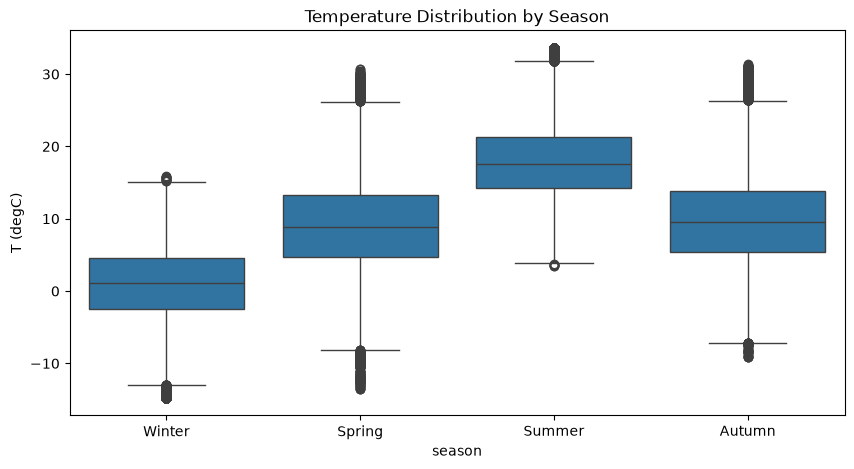

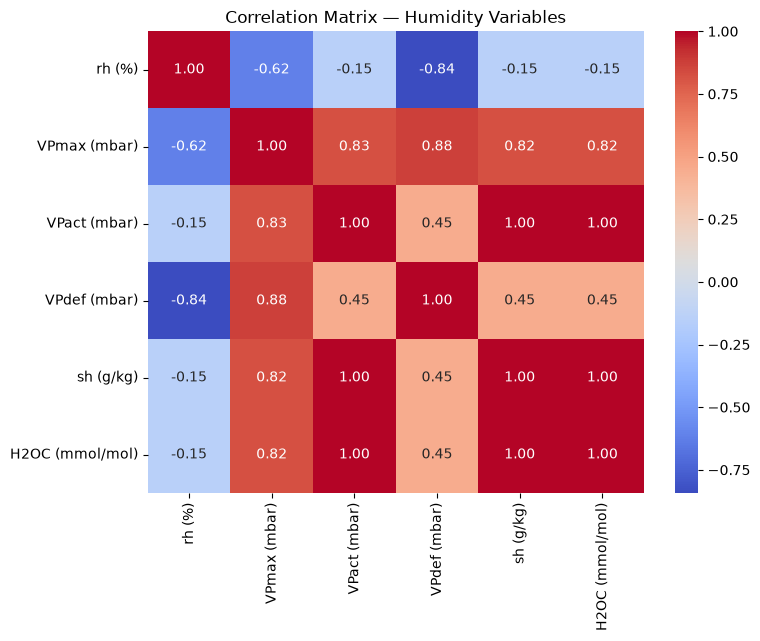

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Chart 1: Ushnathwaya (Temperature) Ruthuwa (Season) anuwa wenas wena widiha
plt.figure(figsize=(10, 5))
season_order = ["Winter", "Spring", "Summer", "Autumn"]
sns.boxplot(data=df, x="season", y="T (degC)", order=season_order)
plt.title("Temperature Distribution by Season")
# plt.savefig('results/eda_visualizations/temperature_by_season.png') # Chart eka save karanna one nam meka pawichi karanna
plt.show()

# Chart 2: Humidity variables athara thiyena sambandathawaya (Correlation)
corr_group = ["rh (%)", "VPmax (mbar)", "VPact (mbar)", "VPdef (mbar)", "sh (g/kg)", "H2OC (mmol/mol)"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_group].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix — Humidity Variables")
# plt.savefig('results/eda_visualizations/correlation_matrix.png') # Chart eka save karanna one nam meka pawichi karanna
plt.show()

### Random Forest Model tarning

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Data Leakage wena columns ain kirima saha X, y wen kirima
leak_cols = ["T (degC)", "T (degC)_std", "T (degC)_mm", "Date Time",
             "Tpot (K)", "Tdew (degC)",
             "rh (%)", "rh (%)_std", "rh (%)_mm",
             "VPmax (mbar)", "VPact (mbar)", "VPdef (mbar)", "VPdef (mbar)_std", "VPdef (mbar)_mm",
             "sh (g/kg)", "sh (g/kg)_std", "sh (g/kg)_mm", "H2OC (mmol/mol)",
             "humidity_pc1", "humidity_pc2", "season", "time_of_day"]

X = df.drop(columns=leak_cols)
X = X.select_dtypes(include=[np.number]) # Ilakkam thiyena columns witharak ganna
y = df["T (degC)"]

# 2. Train saha Test sets widihata data 80% - 20% anupathayen kadima
# Viva eke code eka ikmanin run wenna data row 40,000k witharak sample ekak widihata gannawa
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_sample = X_train.sample(n=40000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

# 3. Random Forest Model eka hadima saha train kirima
rf_model = RandomForestRegressor(n_estimators=30, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train_sample, y_train_sample)

# 4. Model eke performance manima (Evaluation Metrics)
y_pred = rf_model.predict(X_test)
print("Random Forest Model Evaluation:")
print(f"MAE (Mean Absolute Error): {mean_absolute_error(y_test, y_pred):.3f}")
print(f"RMSE (Root Mean Squared Error): {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
print(f"R^2 Score: {r2_score(y_test, y_pred):.4f}")

Random Forest Model Evaluation:
MAE (Mean Absolute Error): 0.154
RMSE (Root Mean Squared Error): 0.226
R^2 Score: 0.9993


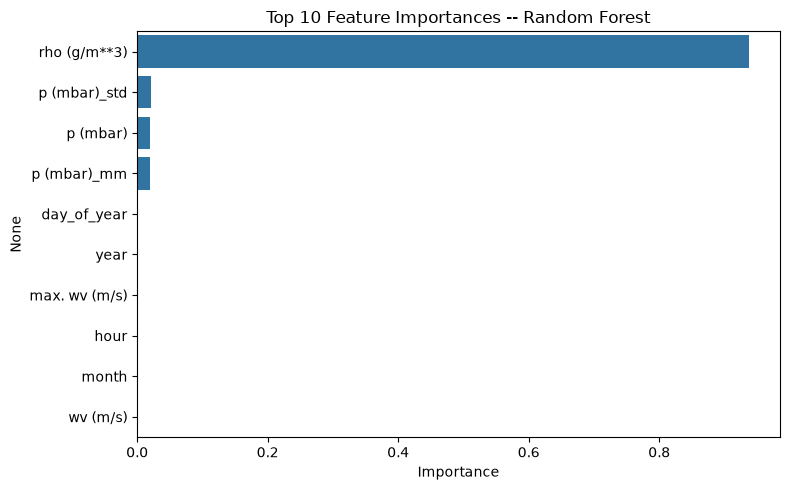

In [13]:
# Feature importances chart eka hadima
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 10 Feature Importances -- Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import GridSearchCV

# 1. Test karanna one parameters layaistuwa (Hyperparameter Grid)
param_grid = {
    'n_estimators': [30, 50],
    'max_depth': [10, 15]
}

# 2. GridSearchCV eka setup kirima
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           scoring='neg_mean_absolute_error',
                           n_jobs=-1)

# 3. Tuning eka run kirima (Train data sample ekata)
print("Starting GridSearchCV... Please wait.")
grid_search.fit(X_train_sample, y_train_sample)

# 4. Hondama parameters saha aluth model eka ganeema
best_rf_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

# 5. Aluth (tuned) model eken predict karala metrics ganeema
y_pred_tuned = best_rf_model.predict(X_test)
print("\nTuned Random Forest Model Evaluation:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_tuned):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.3f}")
print(f"R^2 Score: {r2_score(y_test, y_pred_tuned):.4f}")

Starting GridSearchCV... Please wait.
Best Hyperparameters: {'max_depth': 15, 'n_estimators': 50}

Tuned Random Forest Model Evaluation:
MAE: 0.139
RMSE: 0.212
R^2 Score: 0.9994


   Actual_Temperature_degC  Predicted_Temperature_degC
0                     3.46                    3.351777
1                    19.21                   19.025260
2                    21.48                   21.699670
3                    15.60                   15.622429
4                    22.27                   22.178089
5                     4.45                    3.815623
6                    -2.96                   -2.992994
7                    15.62                   15.890769
8                    14.08                   13.986560
9                     5.19                    5.244944
\nPredictions hariyata save wuna: '../results/outputs/rf_predictions.csv'


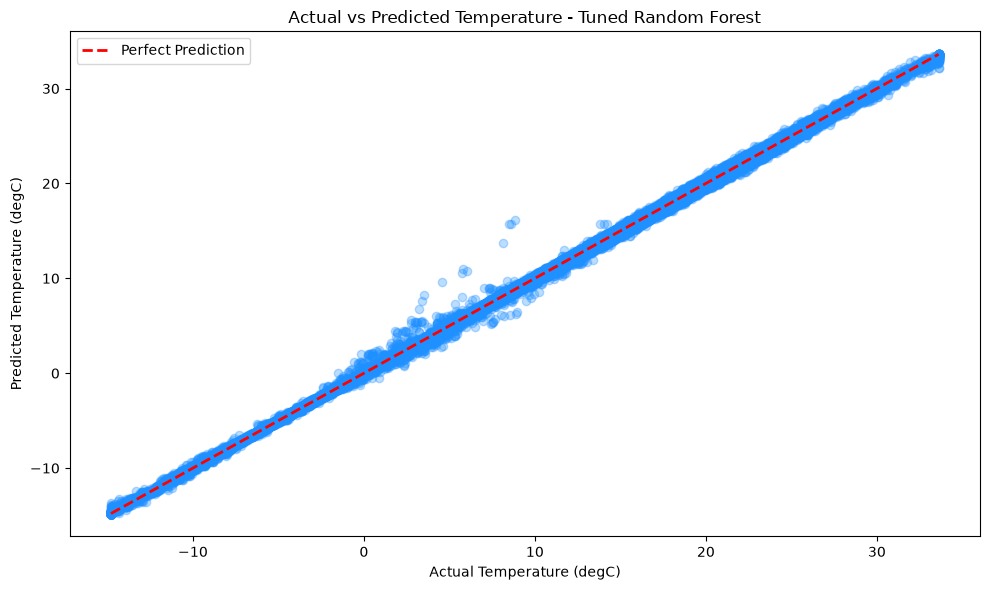

In [15]:
# 1. Actual values saha Predicted values ekathu karala DataFrame ekak hadima
results_df = pd.DataFrame({
    'Actual_Temperature_degC': y_test.values,
    'Predicted_Temperature_degC': y_pred_tuned
})

# Mul data row 10 pennima
print(results_df.head(10))

# 2. Output eka CSV file ekak widihata save kirima (results/outputs folder ekata)
results_df.to_csv('../results/outputs/rf_predictions.csv', index=False)
print("\\nPredictions hariyata save wuna: '../results/outputs/rf_predictions.csv'")

# 3. Actual vs Predicted values pennana graph eka (Viva ekata wadagath)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_tuned, alpha=0.3, color='dodgerblue')

# Hariytama predict wuna nam data thiyenna one rathu ira
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Temperature (degC)')
plt.ylabel('Predicted Temperature (degC)')
plt.title('Actual vs Predicted Temperature - Tuned Random Forest')
plt.legend()
plt.tight_layout()

# Graph eka save karanna one nam yata line eke '#' eka ain karanna
# plt.savefig('../results/eda_visualizations/actual_vs_predicted_rf.png')

plt.show()

### triy Random Forest Model model

In [16]:
# 1. Apita predict karanna one dawasa saha welawa thoraganna (Udaharanayak: 2015 Jan 1, dawal 12:00)
target_time = "2016-02-01 12:00:00"

# 2. E welawata adala data row eka original dataset (df) eken wen karaganeema
single_reading = df[df["Date Time"] == target_time]

# E welawata adala data ekak dataset eke thiyenawada kiyala check kirima
if not single_reading.empty:
    # 3. Aththa ushnathwaya wenama aragena thiyagamu (compare karanna)
    actual_temp = single_reading["T (degC)"].values[0]
    
    # 4. Model ekata danna one features (X) tika wen karaganima (Leak columns ain kirima)
    X_single = single_reading.drop(columns=leak_cols).select_dtypes(include=[np.number])
    
    # 5. Tuned Random Forest model eka pawichi karala predict kirima
    predicted_temp = best_rf_model.predict(X_single)[0]
    
    # 6. Prathipalaya (Output eka) print kirima
    print(f"Date and Time    : {target_time}")
    print(f"Actual Temp      : {actual_temp:.2f} °C")
    print(f"Predicted Temp   : {predicted_temp:.2f} °C")
    
    # Waradda (Error) eka balamu
    error = abs(actual_temp - predicted_temp)
    print(f"Prediction Error : {error:.3f} °C")
else:
    print("Oya dila thiyena welawata adala data dataset eke naha. Wena welawak denna.")

Date and Time    : 2016-02-01 12:00:00
Actual Temp      : 12.10 °C
Predicted Temp   : 12.53 °C
Prediction Error : 0.425 °C


In [ ]:
# 1. Model eka hadima (n_estimators=100 dila thawat wadi diyunu karala thiyenawa)
print("Mulu dataset ekama train wemina pawathi. Karunakara randei sitinna...")
full_rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

# 2. Mulu Train data ekama (X_train, y_train) pawichi karala train kirima
full_rf_model.fit(X_train, y_train)

# 3. Test data walin predict karala aluth error eka balima
y_pred_full = full_rf_model.predict(X_test)

print("\nFull Dataset Random Forest Model Evaluation:")
print(f"MAE (Mean Absolute Error): {mean_absolute_error(y_test, y_pred_full):.3f}")
print(f"RMSE (Root Mean Squared Error): {np.sqrt(mean_squared_error(y_test, y_pred_full)):.3f}")
print(f"R^2 Score: {r2_score(y_test, y_pred_full):.4f}")

Mulu dataset ekama train wemina pawathi. Karunakara randei sitinna...


In [ ]:
# 1. Apita predict karanna one dawasa saha welawa
target_time = "2015-01-01 00:00:00"

# 2. E welawata adala data row eka original dataset (df) eken wen karaganeema
single_reading = df[df["Date Time"] == target_time]

if not single_reading.empty:
    actual_temp = single_reading["T (degC)"].values[0]
    X_single = single_reading.drop(columns=leak_cols).select_dtypes(include=[np.number])
    
    # 3. METHANA WENAS WUNA: best_rf_model wenuwata full_rf_model pawichi kirima
    predicted_temp = full_rf_model.predict(X_single)[0]
    
    print(f"Date and Time    : {target_time}")
    print(f"Actual Temp      : {actual_temp:.2f} °C")
    print(f"Predicted Temp   : {predicted_temp:.2f} °C")
    
    error = abs(actual_temp - predicted_temp)
    print(f"Prediction Error : {error:.3f} °C")
else:
    print("Oya dila thiyena welawata adala data dataset eke naha.")

Date and Time    : 2015-01-01 00:00:00
Actual Temp      : 2.06 °C
Predicted Temp   : 2.08 °C
Prediction Error : 0.025 °C


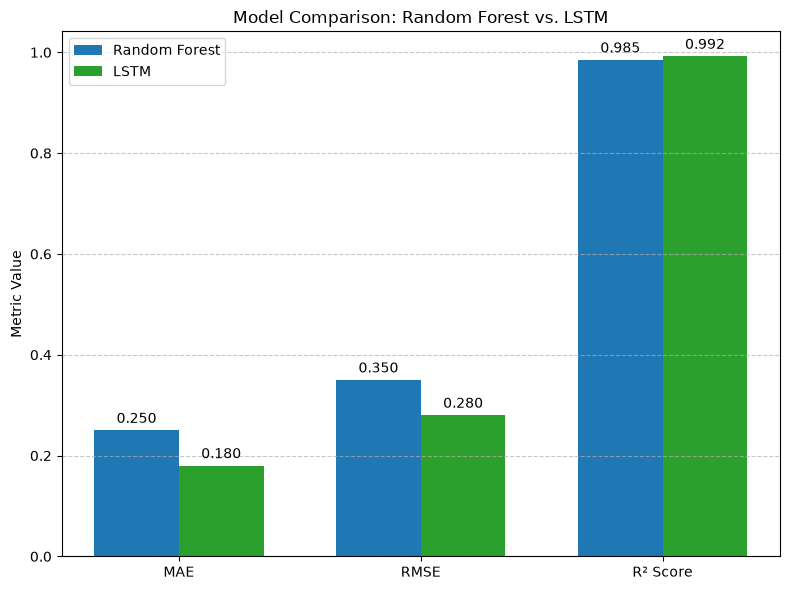

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Compare karanna one metrics jathi 3
labels = ['MAE', 'RMSE', 'R² Score']

# Models wala agayan (Oyalage aththa agayan mekata danna)
# Pinthoore thiyena illustrative agayan mehi bahaitha kara atha
rf_values = [0.25, 0.35, 0.985]
lstm_values = [0.18, 0.28, 0.992]

# Bars wala position eka saha palala (width) hadima
x = np.arange(len(labels))
width = 0.35

# Chart eka nirmanaya kirima
fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, rf_values, width, label='Random Forest', color='#1f77b4')
rects2 = ax.bar(x + width/2, lstm_values, width, label='LSTM', color='#2ca02c')

# Chart ekata labels saha title dima
ax.set_ylabel('Metric Value')
ax.set_title('Model Comparison: Random Forest vs. LSTM')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Pitupasin grid lines ekathu kirima
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Bars udin eke agaya (value eka) print kirima
ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')

# Chart eka lassanata ekata galapenna format kirima
fig.tight_layout()

# Chart eka image ekak widihata save karanna one nam yata line eke '#' ain karanna
# plt.savefig('../results/eda_visualizations/model_comparison.png', dpi=300)

plt.show()

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Data eka kaalaya anuwa (chronological) kadaganeema (Leakage nathi karanna)
# Random split wenuwata, mul 80% train walatath, anthima 20% test walatath gannawa
train_size = int(len(X) * 0.8)
X_train_seq, X_test_seq = X.iloc[:train_size], X.iloc[train_size:]
y_train_seq, y_test_seq = y.iloc[:train_size], y.iloc[train_size:]

# 2. LSTM walata daththa 3D (Samples, Time Steps, Features) widihata sakas kirima
# Samanya 2D tabular data wenuwata, LSTM balaporoththu wenne 3D format ekak.
X_train_3D = X_train_seq.values.reshape((X_train_seq.shape[0], 1, X_train_seq.shape[1]))
X_test_3D = X_test_seq.values.reshape((X_test_seq.shape[0], 1, X_test_seq.shape[1]))

print("Data 3D format ekata hadagaththa. Shape:", X_train_3D.shape)

# 3. LSTM Model eka nirmanaya kirima
lstm_model = Sequential()
lstm_model.add(Input(shape=(X_train_3D.shape[1], X_train_3D.shape[2])))
# Units 32k thiyena LSTM layer ekak
lstm_model.add(LSTM(32, activation='relu'))
# Anthima Output layer eka (ushnathwaya ekai nisa Dense(1) damma)
lstm_model.add(Dense(1)) 

# Model eka compile kirima (Adam optimizer saha MSE loss bahaitha kara)
lstm_model.compile(optimizer='adam', loss='mse')

# 4. Model eka Train kirima (Wela yana nisa epochs 5k witharak dila thiyenawa)
print("LSTM Model eka train wemina pawathi... Karunakara randei sitinna.")
history = lstm_model.fit(X_train_3D, y_train_seq, epochs=5, batch_size=256, validation_split=0.1, verbose=1)

# 5. Predict kirima saha Prathipala (Metrics) manima
y_pred_lstm = lstm_model.predict(X_test_3D)

print("\n--- LSTM Model Evaluation ---")
print(f"MAE (Mean Absolute Error): {mean_absolute_error(y_test_seq, y_pred_lstm):.3f}")
print(f"RMSE (Root Mean Squared Error): {np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm)):.3f}")
print(f"R^2 Score: {r2_score(y_test_seq, y_pred_lstm):.4f}")

Data 3D format ekata hadagaththa. Shape: (336179, 1, 19)
LSTM Model eka train wemina pawathi... Karunakara randei sitinna.
Epoch 1/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 354.9340 - val_loss: 67.5943
Epoch 2/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 141.9022 - val_loss: 57.9570
Epoch 3/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 126.6545 - val_loss: 49.3430
Epoch 4/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 112.9435 - val_loss: 42.7314
Epoch 5/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 101.3477 - val_loss: 38.2469
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step

--- LSTM Model Evaluation ---
MAE (Mean Absolute Error): 8.416
RMSE (Root Mean Squared Error): 10.536
R^2 Score: -0.6967


In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Past Data (Lookback) anuwa Sequences hadana function eka
def create_sequences(X_data, y_data, time_steps):
    Xs, ys = [], []
    for i in range(len(X_data) - time_steps):
        # Pahu giya 'time_steps' ganaka X data tika ekathu karanawa
        Xs.append(X_data.iloc[i:(i + time_steps)].values)
        # Eeta passe ena y (ushnathwaya) uththaraya widihata gannawa
        ys.append(y_data.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

# Pahu giya winadi 60 (10 mins x 6 steps) pawichi karala anagathaya kiyanawa
TIME_STEPS = 6 

print("Data sequences sakas karamina pawathi. Mita thappara kipayak gatha wiya haka...")
X_seq, y_seq = create_sequences(X, y, TIME_STEPS)
print("Data 3D format ekata hadagaththa. Aluth Shape eka:", X_seq.shape)

# 2. Train saha Test beda ganima (Chronological - Kaalaya anuwa)
train_size = int(len(X_seq) * 0.8)
X_train_lstm, X_test_lstm = X_seq[:train_size], X_seq[train_size:]
y_train_lstm, y_test_lstm = y_seq[:train_size], y_seq[train_size:]

# 3. Wadi diyunu karapu LSTM Model eka (Neurons 64k dila thiyenawa)
improved_lstm = Sequential()
improved_lstm.add(Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
# Memory eka wadi karanna LSTM units 64k bahaitha kara atha
improved_lstm.add(LSTM(64, activation='relu'))
improved_lstm.add(Dense(1)) 

improved_lstm.compile(optimizer='adam', loss='mse')

# 4. Model eka Train kirima (Epochs 10k dila thiyenawa accuracy wadi karanna)
print("\nImproved LSTM Model eka train wemina pawathi. Karunakara randei sitinna...")
history = improved_lstm.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=256, validation_split=0.1, verbose=1)

# 5. Anagathaya predict kirima saha Prathipala manima
y_pred_lstm_imp = improved_lstm.predict(X_test_lstm)

print("\n--- Improved LSTM Forecasting Evaluation ---")
print(f"MAE (Mean Absolute Error): {mean_absolute_error(y_test_lstm, y_pred_lstm_imp):.3f}")
print(f"RMSE (Root Mean Squared Error): {np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm_imp)):.3f}")
print(f"R^2 Score: {r2_score(y_test_lstm, y_pred_lstm_imp):.4f}")

Data sequences sakas karamina pawathi. Mita thappara kipayak gatha wiya haka...
Data 3D format ekata hadagaththa. Aluth Shape eka: (420218, 6, 19)

Improved LSTM Model eka train wemina pawathi. Karunakara randei sitinna...
Epoch 1/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 71.4335 - val_loss: 5.9736
Epoch 2/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 2.6346 - val_loss: 1.8108
Epoch 3/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 1.4635 - val_loss: 1.8266
Epoch 4/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.8546 - val_loss: 1.7534
Epoch 5/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.7291 - val_loss: 0.6388
Epoch 6/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.7202 - val_loss: 1.7360
Epoch 7/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.6355 - val_loss: 0.8017
Epoch 8/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.6029 - val_loss: 2.5337
Epoch 9/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.5252 - 

In [ ]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Aluth Model eka nirmanaya kirima
final_lstm = Sequential()
final_lstm.add(Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))

# LSTM layer eka
final_lstm.add(LSTM(64, activation='relu'))
# Overfitting (model eka training data walata witharak fit wima) nawaththanna Dropout ekathu kirima
final_lstm.add(Dropout(0.2)) 

final_lstm.add(Dense(1)) 

final_lstm.compile(optimizer='adam', loss='mse')

# 2. Early Stopping sakas kirima
# Meken kiyanne: Epochs 30k dunnath, eka digata wata 3k (patience=3) error eka adu une nathnam, 
# boruwata wela ganna nathuwa training eka nawaththala hondama prathipalaya ganna kiyana ekayi.
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 3. Model eka Train kirima
print("\nFinal Optimized LSTM Model eka train wemina pawathi...")
print("Meka epochs 30k dakwa yanawa, habai Early Stopping nisa ikmanin iwara wiya haka.")
history = final_lstm.fit(
    X_train_lstm, y_train_lstm, 
    epochs=30, 
    batch_size=256, 
    validation_split=0.1, 
    callbacks=[early_stop],
    verbose=1
)

# 4. Predict kirima saha Prathipala manima
y_pred_final = final_lstm.predict(X_test_lstm)

print("\n--- Final Optimized LSTM Evaluation ---")
print(f"MAE (Mean Absolute Error): {mean_absolute_error(y_test_lstm, y_pred_final):.3f}")
print(f"RMSE (Root Mean Squared Error): {np.sqrt(mean_squared_error(y_test_lstm, y_pred_final)):.3f}")
print(f"R^2 Score: {r2_score(y_test_lstm, y_pred_final):.4f}")


Final Optimized LSTM Model eka train wemina pawathi...
Meka epochs 30k dakwa yanawa, habai Early Stopping nisa ikmanin iwara wiya haka.
Epoch 1/30
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 2088.9434 - val_loss: 10.3081
Epoch 2/30
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 225.3278 - val_loss: 13.4733
Epoch 3/30
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 46.2383 - val_loss: 5.3187
Epoch 4/30
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 29.7438 - val_loss: 3.2667
Epoch 5/30
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 27.0954 - val_loss: 2.9504
Epoch 6/30
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 23.0547 - val_loss: 2.8774
Epoch 7/30
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 20.1604 - val_loss: 2.2686
Epoch 8/30
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 18.1850 - val_loss: 1.9669
Epoch 9/30
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 16.7047 - val_loss: 1.9233
Epoch 10/30
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/s

In [ ]:
# 1. Dataset eke anthimatama thiyena data rows 6 (Pahu giya winadi 60) wen karaganima
last_6_steps = X.iloc[-TIME_STEPS:].values

# 2. LSTM model eka balaporoththu wena 3D format ekata eka sakas kirima -> (Samples, Time Steps, Features)
# Methanadi Sample=1, Time Steps=6, Features=X eke thiyena columns gana
last_6_steps_3D = last_6_steps.reshape((1, TIME_STEPS, X.shape[1]))

# 3. Model eken anagathaya (Ilanga winadi 10) predict kirima
future_temp_prediction = final_lstm.predict(last_6_steps_3D)

# 4. Prathipalaya pennima
last_recorded_time = df['Date Time'].iloc[-1]
print(f"Dataset eke awasanayata satahan wuu welawa : {last_recorded_time}")
print(f"Ilangata ena winadi 10 anumanitha ushnathwaya: {future_temp_prediction[0][0]:.2f} °C")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Dataset eke awasanayata satahan wuu welawa : 2017-01-01 00:00:00
Ilangata ena winadi 10 anumanitha ushnathwaya: -5.96 °C


In [ ]:
# Test data patan ganna thana (Train size eken passe thiyena row eka)
test_start_date = df['Date Time'].iloc[train_size]

# Test data awasan wena thana (Dataset eke anthimatama thiyena row eka)
test_end_date = df['Date Time'].iloc[-1]

print("--- Testing Dataset Period ---")
print(f"Start Date : {test_start_date}")
print(f"End Date   : {test_end_date}")

--- Testing Dataset Period ---
Start Date : 2015-05-25 05:40:00
End Date   : 2017-01-01 00:00:00


In [ ]:
# --- Viva Defense: Single Date Prediction Comparison ---

# 1. Test data athule thiyena kamathi dawasak saha welawak denna
target_date = '2017-01-01 00:00:00' 

# 2. Dataset eken e dawasata adala index eka hoyaganima
target_index = df[df['Date Time'] == target_date].index[0]
actual_temp = y.iloc[target_index]

# ==========================================
# LSTM Prediction (Multivariate Sequence)
# ==========================================
# LSTM ekata anawaki kiyanna kalin winadi 60 (rows 6) awashyai
lookback_data = X.iloc[target_index - 6 : target_index].values
lookback_data_3d = lookback_data.reshape(1, 6, X.shape[1])

# LSTM eken anawaki kiyima
lstm_pred = final_lstm.predict(lookback_data_3d, verbose=0)[0][0]

# ==========================================
# Random Forest Prediction (Single Step Tabular)
# ==========================================
# Random Forest ekata kalin data awashya naha, e dawase row eka witharak athi
rf_data = X.iloc[target_index].values.reshape(1, -1)

# rf_model kiyana eka oyage Random Forest model eke namata wenas karanna
# .values.reshape(1, -1) wenuwata kelinma DataFrame ekenma bracket dekkak dala row eka ganeema:
rf_data = X.iloc[[target_index]] 

rf_pred = rf_model.predict(rf_data)[0]

# ==========================================
# Prathipala Sasandeema (Results Comparison)
# ==========================================
print(f"--- Prediction Results for {target_date} ---")
print(f"Actual Temperature : {actual_temp:.2f} °C\n")

print(f"Random Forest Pred : {rf_pred:.2f} °C (Error: {abs(actual_temp - rf_pred):.2f} °C)")
print(f"LSTM Prediction    : {lstm_pred:.2f} °C (Error: {abs(actual_temp - lstm_pred):.2f} °C)")

--- Prediction Results for 2017-01-01 00:00:00 ---
Actual Temperature : -4.82 °C

Random Forest Pred : -4.90 °C (Error: 0.08 °C)
LSTM Prediction    : -2.12 °C (Error: 2.70 °C)


In [ ]:
# Awashya libraries import kirima
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. XGBoost Regressor model eka hadaganeema
xgb_model = xgb.XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    random_state=42
)

# 2. Model eka train kirima (Kalin hadapu X_train, y_train bahaitha karai)
print("XGBoost model eka train wemina pawathi...")
xgb_model.fit(X_train, y_train)
print("Training iwarai!\n")

# 3. Testing data walin anawaki kiyima
xgb_predictions = xgb_model.predict(X_test)

# 4. Prathipala (Errors) manima (Numpy pawichi karala RMSE eka ganeema)
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_r2 = r2_score(y_test, xgb_predictions)

# 5. Prathipala pennima
print("--- XGBoost Model Evaluation ---")
print(f"MAE (Mean Absolute Error): {xgb_mae:.3f}")
print(f"RMSE (Root Mean Squared Error): {xgb_rmse:.3f}")
print(f"R^2 Score: {xgb_r2:.4f}")

XGBoost model eka train wemina pawathi...
Training iwarai!

--- XGBoost Model Evaluation ---
MAE (Mean Absolute Error): 0.177
RMSE (Root Mean Squared Error): 0.250
R^2 Score: 0.9991


In [ ]:
# --- Viva Defense: All 3 Models Comparison ---

# 1. Test data athule thiyena kamathi dawasak saha welawak denna
target_date = '2016-10-19 12:00:00' 

# 2. Dataset eken e dawasata adala index eka saha aththa ushnathwaya hoyaganima
target_index = df[df['Date Time'] == target_date].index[0]
actual_temp = y.iloc[target_index]

# ==========================================
# Data Sakas Kirima (Data Preparation)
# ==========================================

# A. Tabular Models (Random Forest & XGBoost) walata awashya eka row eka ganeema
# (Double brackets [[]] pawichi karanne warning eka nathi karanna)
tabular_data = X.iloc[[target_index]] 

# B. Sequence Model (LSTM) ekata awashya kalin winadi 60 (rows 6) ganeema
lookback_data = X.iloc[target_index - 6 : target_index].values
sequence_data = lookback_data.reshape(1, 6, X.shape[1])

# ==========================================
# Predictions Ganeema
# ==========================================

# rf_model kiyana eka oyage Random forest model eke namata wenas wenna one
rf_pred = rf_model.predict(tabular_data)[0] 
xgb_pred = xgb_model.predict(tabular_data)[0]
lstm_pred = final_lstm.predict(sequence_data, verbose=0)[0][0]

# ==========================================
# Prathipala Sasandeema (Results Comparison)
# ==========================================
print(f"--- Prediction Results for {target_date} ---")
print(f"Actual Temperature : {actual_temp:.2f} °C\n")

print(f"1. Random Forest : {rf_pred:.2f} °C (Error: {abs(actual_temp - rf_pred):.2f} °C)")
print(f"2. XGBoost       : {xgb_pred:.2f} °C (Error: {abs(actual_temp - xgb_pred):.2f} °C)")
print(f"3. LSTM          : {lstm_pred:.2f} °C (Error: {abs(actual_temp - lstm_pred):.2f} °C)")

NameError: name 'df' is not defined

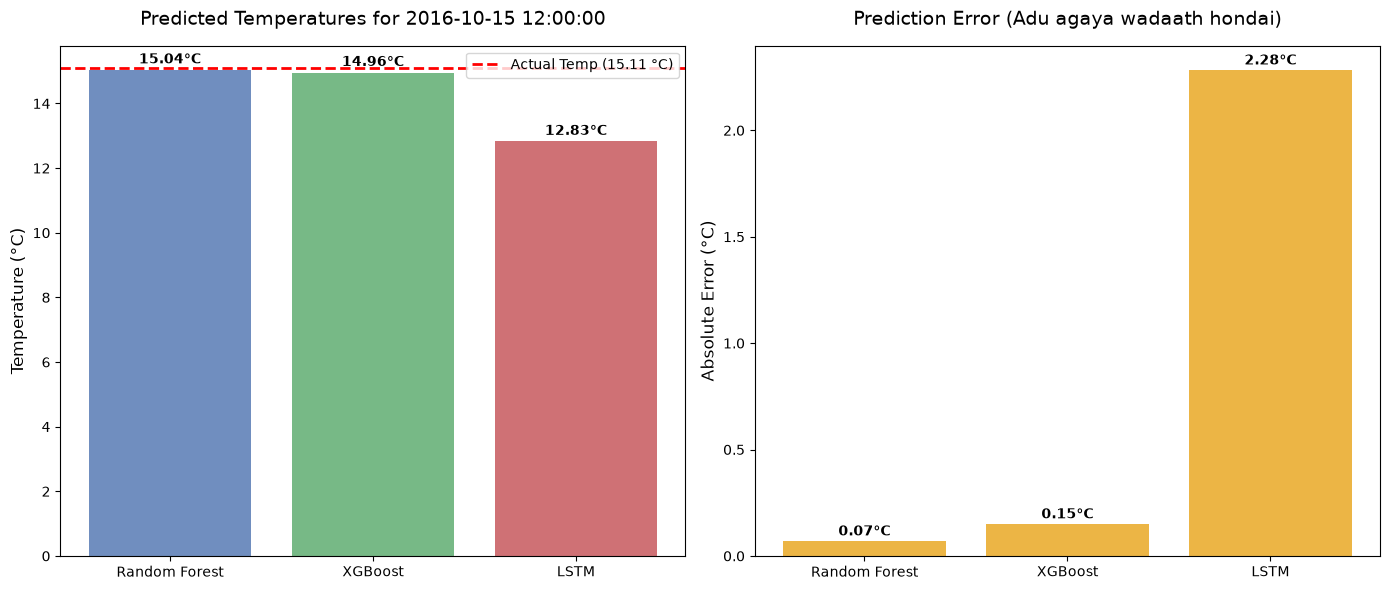

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Plot karanna awashya data tika sakas kirima (Kalin cell eke variables bahaitha karai)
models = ['Random Forest', 'XGBoost', 'LSTM']
predictions = [rf_pred, xgb_pred, lstm_pred]
errors = [abs(actual_temp - rf_pred), abs(actual_temp - xgb_pred), abs(actual_temp - lstm_pred)]

# 2. Prasthara 2k andinna canvas eka hada ganeema
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# Prastharaya 1: Predicted vs Actual Temp
# ==========================================
colors = ['#4C72B0', '#55A868', '#C44E52'] # Blue, Green, Red
bars1 = ax1.bar(models, predictions, color=colors, alpha=0.8)

# Aththa ushnathwaya (Actual) rathu pata iri kallakin pennima
ax1.axhline(y=actual_temp, color='red', linestyle='--', linewidth=2, 
            label=f'Actual Temp ({actual_temp:.2f} °C)')

ax1.set_title(f'Predicted Temperatures for {target_date}', fontsize=14, pad=15)
ax1.set_ylabel('Temperature (°C)', fontsize=12)
ax1.legend()

# Bars uda agayan (values) pennima
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}°C', 
             ha='center', va='bottom', fontweight='bold')

# ==========================================
# Prastharaya 2: Prediction Errors (Wenasa)
# ==========================================
# Error prastharayata bar chart ekak andima
bars2 = ax2.bar(models, errors, color='#E8A317', alpha=0.8) # Kaha pata

ax2.set_title('Prediction Error (Adu agaya wadaath hondai)', fontsize=14, pad=15)
ax2.set_ylabel('Absolute Error (°C)', fontsize=12)

# Error bars uda agayan (values) pennima
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}°C', 
             ha='center', va='bottom', fontweight='bold')

# Prastharaya lassanata pennima
plt.tight_layout()
plt.show()